<a href="https://www.kaggle.com/code/daniellevenstein/stress-vs-physical-activity-correlation?scriptVersionId=299210872" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<a href="https://www.kaggle.com/code/daniellevenstein/stress-vs-physical-activity-correlation?scriptVersionId=298949504" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Sleep Health Correlation Notebook
## Notebook Summary

This project explores the relationship between total activity levels and self-reported stress across different occupations. The goal was to identify whether higher activity is associated with increased stress and whether occupation plays a meaningful role in that relationship.

The analysis includes:

- Data cleaning and occupation-level filtering
- Exploratory data analysis (EDA)
- Correlation analysis
- K-means clustering to identify patterns in activity and stress

Several distinct clusters were identified when analyzing the full dataset, suggesting meaningful population-level groupings. However, when the data were examined within individual occupations, these cluster patterns were not consistently reproduced. In several cases, clear correlations appeared to be influenced by outliers rather than stable occupation-level trends.

These results suggest that the relationship between activity and stress is more visible at the aggregate level than within specific occupations. Several occupations were also excluded due to insufficient sample sizes, limiting subgroup analysis.

## Methodology
In this project I created a combined metric called Total_Physical_Activity which combined the data from the Daily Steps a Physical Activity Column. This allowed me to create more readable charts and allowed be to quickly determine the correlation between different samples within clusters.
## Experiments
On looking at the initial Stress vs. Physical Activity data, I saw what looked like 2–3 distinct clusters in the raw data, so I ran the kmeans algorithm on the data twice, once for two clusters and once for three. I found that both cluster groups were potentially useful. The two cluster data were more stable over time; therefore, I think it's a more accurate description of the underling patterns.

## Import Dependencies

In [1]:
!pip install -q kagglehub pandas seaborn matplotlib scikit-learn

In [2]:
import pandas as pd
import kagglehub
import seaborn as sns
import shutil
import os
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

## Load Data

In [3]:
DATA_DIR="data"
IMG_DIR="images"
# Create the data directory if it doesn't exist
os.makedirs("data", exist_ok=True)
os.makedirs("images", exist_ok=True)
# Download dataset from kagglehub
path = kagglehub.dataset_download("uom190346a/sleep-health-and-lifestyle-dataset",
                                  "Sleep_health_and_lifestyle_dataset.csv")
TWO_CLUSTER_IMAGE=IMG_DIR+"/Stress_Level_by_Cluster_2.png"
TWO_CLUSTER_IMAGE_EXTENDED=IMG_DIR+"/Stress_Level_by_Cluster_2_Expanded.png"
THREE_CLUSTER_IMAGE_EXTENDED=IMG_DIR+"/Stress_Level_by_Cluster_3_Expanded.png"

THREE_CLUSTER_IMAGE=IMG_DIR+"/Stress_Level_by_Cluster_3.png"
SIDE_BY_SIDE_CLUSTERS=IMG_DIR+"/Stress_Level_by_Cluster_Side_by_Side.png"

## Data Summary

In [4]:
# Copy file to the data directory
destination = DATA_DIR+"/Sleep_health_and_lifestyle_dataset.csv"
shutil.copy(path, destination)
print(f"Dataset copied to {destination}")
df = pd.read_csv(DATA_DIR+"/Sleep_health_and_lifestyle_dataset.csv")
df.drop("Person ID", axis=1, inplace=True)
df.head()

Dataset copied to data/Sleep_health_and_lifestyle_dataset.csv


,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


# Notebook EDA
## Original Occupation List

In [5]:
df_copy = df.copy()
categorical_columns = df_copy.columns[df_copy.dtypes == 'str']

# Deleting lawyer data in both original data and due to insufficient data.
occupation_stress = df.groupby('Occupation')['Stress Level'].describe()
print("\nStress Level by Occupation:")
occupation_stress.head(10)


Stress Level by Occupation:


,count,mean,std,min,25%,50%,75%,max
Occupation,,,,,,,,
Accountant,37.0,4.594595,1.235122,3.0,4.0,4.0,4.0,7.0
Doctor,71.0,6.732394,1.372773,3.0,6.0,6.0,8.0,8.0
Engineer,63.0,3.888889,1.137500,3.0,3.0,3.0,5.0,7.0
Lawyer,47.0,5.063830,0.247092,5.0,5.0,5.0,5.0,6.0
Manager,1.0,5.000000,NaN,5.0,5.0,5.0,5.0,5.0
Nurse,73.0,5.547945,2.392355,3.0,3.0,6.0,8.0,8.0
Sales Representative,2.0,8.000000,0.000000,8.0,8.0,8.0,8.0,8.0
Salesperson,32.0,7.000000,0.000000,7.0,7.0,7.0,7.0,7.0
Scientist,4.0,7.000000,1.154701,6.0,6.0,7.0,8.0,8.0


## Data Cleaning

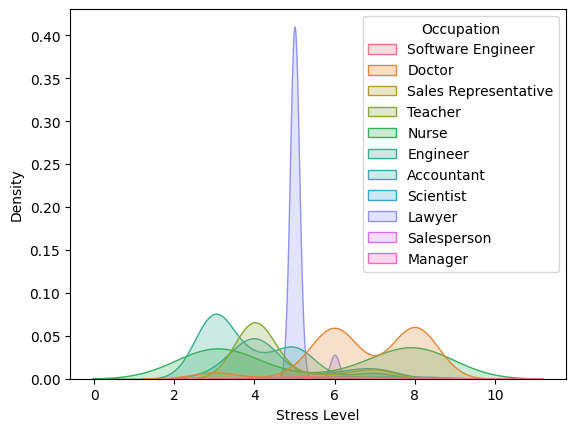

In [6]:
sns.kdeplot(data=df, x="Stress Level", hue="Occupation", fill=True, warn_singular=False);

*Figure Shows stress level for the whole population prior to data cleaning*
### Removing Occupations
- I'm removing the Manager and Sales Representative occupation from the dataset due to a low sample count
- I'm removing Lawyer and Salesperson due to having a standard deviation of 0 which likely indicates the data is synthetic.
- I'm saving the Sales Representative data to a new data frame because it's usefulness is borderline.

In [7]:
removed_occupations = ['Lawyer', 'Manager', 'Salesperson', 'Sales Representative']
df_copy = df.copy()
df_clean = df[~df['Occupation'].isin(removed_occupations)]

## Categorial Column Charts
### Occupation vs. Stress

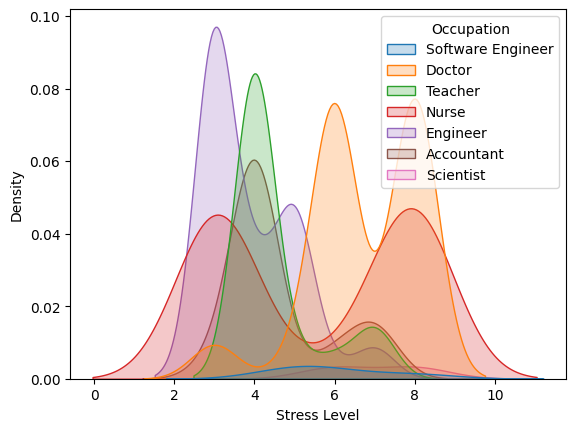

In [8]:
### Deleting outliers from dataset.
df_copy = df_clean.copy()
sns.kdeplot(data=df_copy, x="Stress Level", hue="Occupation", fill=True, warn_singular=False);


*Figure Shows stress level for the whole population by occupation with outlier removed*
#### Observations
- Occupation vs stress chart looks a lot cleaner after outliers are removed.

In [9]:
## Categorical Columns
categorical_columns = df.select_dtypes(include=['object', 'string']).columns
df[categorical_columns].describe()

,Gender,Occupation,BMI Category,Blood Pressure,Sleep Disorder
count,374,374,374,374,155
unique,2,11,4,25,2
top,Male,Nurse,Normal,130/85,Sleep Apnea
freq,189,73,195,99,78


### Sleep Disorders vs. Stress

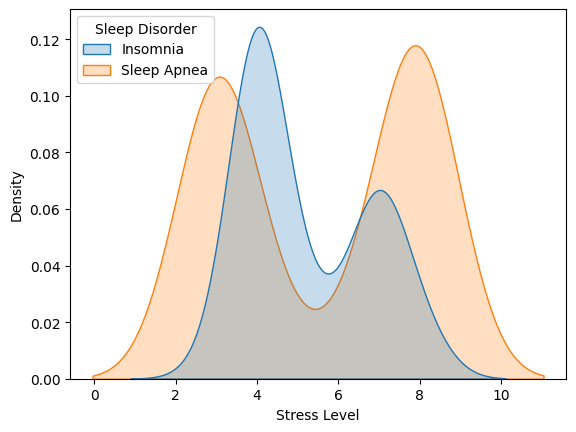

In [10]:
sns.kdeplot(data=df_copy, x="Stress Level", hue="Sleep Disorder", fill=True, warn_singular=False);

*Figure shows how stress level correlates with Insomnia and Sleep Apnea*
#### Observations
- The correlation between insomnia and stress is clearly visible but not as pronounced as expected.
- The correlation between sleep apnea and stress is even weeker.

### Gender vs. Stress

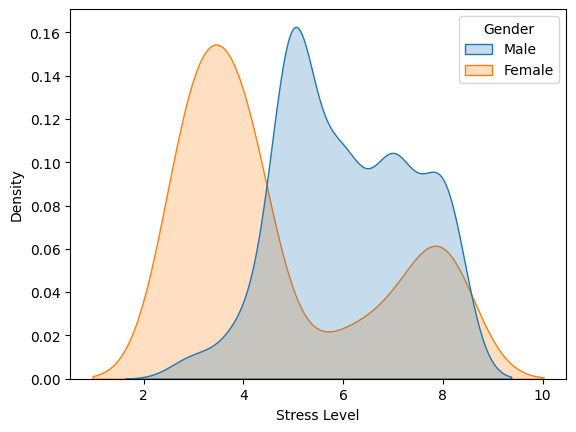

In [11]:
sns.kdeplot(data=df, x="Stress Level", hue="Gender", fill=True, warn_singular=False);

*Figure shows how stress varies by gender*
#### Observation
- On Average, men seem to have a higher stress level than women.

## Data Conversion
- Converting categorical variables to numerical ones

In [12]:
pd.options.mode.chained_assignment = None
# Gender Conversion:
df_copy = df_clean.copy()
df_copy['Gender'] = df_clean['Gender'].map({'Male': 1, 'Female': 0})
# The blood pressure conversion
df_copy['BP_Systolic'] = df_clean['Blood Pressure'].str.split('/').str[0]
df_copy['BP_Diastolic'] = df_clean['Blood Pressure'].str.split('/').str[1]
df_copy['BP_Systolic'] = pd.to_numeric(df_copy['BP_Systolic'])
df_copy['BP_Diastolic'] = pd.to_numeric(df_copy['BP_Diastolic'])
df_copy.drop("Blood Pressure", axis=1, inplace=True)
# BMI conversion
df_copy['BMI_Numerical'] = df_clean['BMI Category'].map({
    'Normal': (18.5 + 24.9 )/2,
    'Normal Weight': (18.5 + 24.9 )/2,
    'Overweight': (25 + 29.9 )/2,
    'Obese': (30 + 34.9 )/2
})
print("Data Cleaned Successfully")
df_clean = df_copy
numerical_columns = df_clean.select_dtypes(include=['number']).columns
df_clean[numerical_columns].describe()


Data Cleaned Successfully


,Gender,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,BP_Systolic,BP_Diastolic,BMI_Numerical
count,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000
mean,0.376712,42.568493,7.176370,7.386986,59.126712,5.243151,69.931507,6801.027397,128.102740,84.527397,24.146062
std,0.485394,9.640912,0.845865,1.223019,21.730330,1.911923,4.248562,1696.458502,8.654284,6.947714,3.036059
min,0.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000,115.000000,75.000000,21.700000
25%,0.000000,33.000000,6.375000,6.000000,40.000000,4.000000,68.000000,5000.000000,120.000000,80.000000,21.700000
50%,0.000000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000,125.000000,80.000000,21.700000
75%,1.000000,51.000000,7.900000,8.000000,75.000000,7.000000,72.000000,8000.000000,135.000000,90.000000,27.450000
max,1.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000,142.000000,95.000000,32.450000


## Numerical Column Correlations

In [13]:
df_agg = df_clean.copy()

def sleep_quality_correlation(df_clean, ax1):
    # Combining Sleep Duration and Quality of Sleep into a single metric
    df_agg['Sleep_Quality'] = (df_clean['Quality of Sleep'] + df_clean['Sleep Duration']) / 2
    sns.scatterplot(data=df_agg, x="Sleep_Quality", hue="Stress Level", y="Stress Level", palette="coolwarm", ax=ax1)
    ax1.set_title("Sleep Quality vs Stress Level")
    sns.regplot(data=df_agg, x="Sleep_Quality", y="Stress Level", scatter=False, color="black", ax=ax1);
def heart_rate_correlation(df, ax2):
    ax2.set_title("Heart Rate vs Stress Level: Regression Plot")
    sns.scatterplot(data=df, x="Heart Rate", y="Stress Level", hue="Stress Level", palette="coolwarm")
    sns.regplot(data=df, x="Heart Rate", y="Stress Level", scatter=False, color="black");

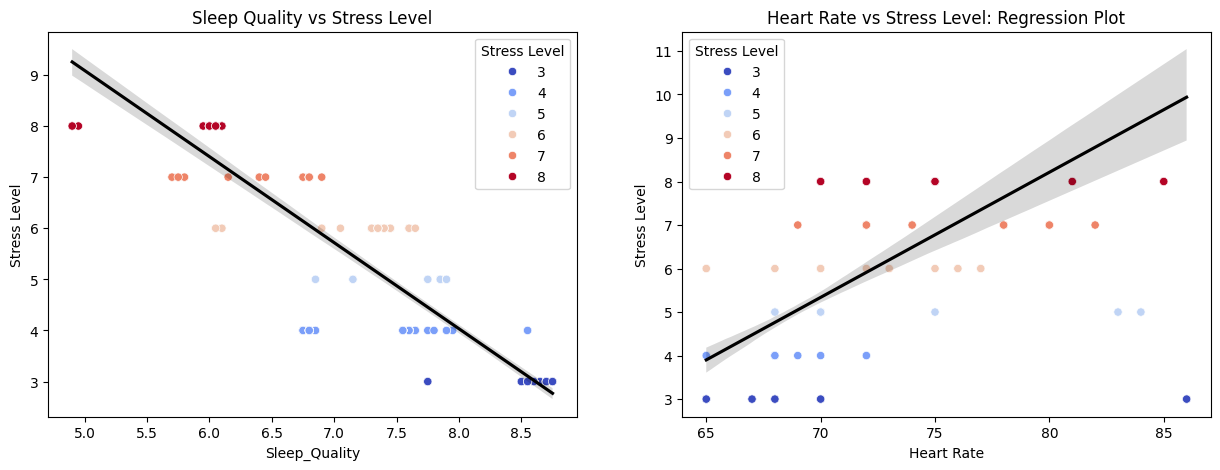

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
sleep_quality_correlation(df_clean, ax1)
heart_rate_correlation(df, ax2)

*Figure right shows the correlation between sleep quality and stress levels with sleep quality and duration of sleep combined into a single metric.*
*Figure left shows correlation between heart rate and stress levels*
#### Observations
- There is a strong negative correlation between sleep quality and stress level.
- Individuals with the highest stress level all rate their sleep duration and quality of sleep poorly.
- There is a clear correlation between heart rate and stress.

## Data Correlation

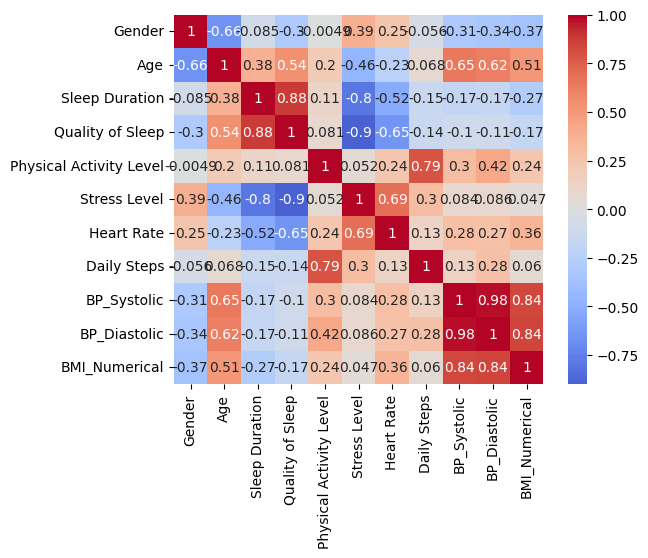

In [15]:
numerical_columns = df_clean.select_dtypes(include=['number']).columns
sns.heatmap(df_clean[numerical_columns].corr(), annot=True, cmap='coolwarm', center=0, square=True);

## EDA Summary
- Sleep quality is correlated with lower stress levels, lower BMI, and lower heart rate.
- Lower heart rate is highly correlated with lower stress levels.

# Detailed Analysis
In this section I will analyze the correlation between physical activity levels and stress using a combination of clustering and feature engineering. The correlations found in this section did not show up when plotting individual features.

## Normalized Data
- Normalize numerical data as values between 0 and 1 to improve the interoperability of results.

In [16]:

def normalize_data(df_clean):
    numerical_columns = df_clean.select_dtypes(include=['number']).columns
    scaler = MinMaxScaler(feature_range=(0, 10))

    df_clean[numerical_columns] = scaler.fit_transform(df_clean[numerical_columns])
    df_normalized = df_clean[numerical_columns]
    print(df_normalized.columns)

    # Using the original stress score to normalized_df since it's already between 1 and 10
    df_normalized['Stress Level'] = df_copy['Stress Level']
    ### Write clean data to csv file
    df_normalized = df_normalized.round(1)
    return df_normalized
df_normalized = normalize_data(df_clean)

Index(['Gender', 'Age', 'Sleep Duration', 'Quality of Sleep',
       'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps',
       'BP_Systolic', 'BP_Diastolic', 'BMI_Numerical'],
      dtype='object')


## Physical Activity vs. Stress

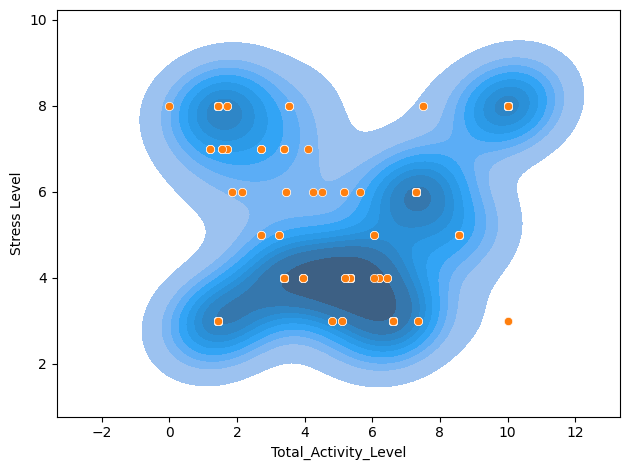

In [17]:
# Creating combined metric including Daily Step count and Physical Activity level
df_agg['Total_Activity_Level'] = (df_normalized['Physical Activity Level'] + df_normalized['Daily Steps']) / 2

sns.kdeplot(data=df_agg, x="Total_Activity_Level", y="Stress Level", fill=True)
sns.scatterplot(data=df_agg, x="Total_Activity_Level", y="Stress Level");
plt.tight_layout()

*Figure left shows a combined metric Total_Activity_Level and displays its correlation to stress levels*

### Observations
- In this chart I combined "Physical Activity Levels" and "Daily Steps" into a single metric for visualization purposes.
- I expected to see a clear negative correlation between total activity levels and stress levels, but instead I see two to three distinct clusters, some of which have a positive correlation between values and some with a negative correlation.

### Next Steps
- I plan to run the k-means algorithm with k=2 and k=3 to analyze the composition of these clusters independently.

## Three Cluster Analyses
The three-cluster analysis was performed to explore finer-grained structure within the activity–stress data. While the two-cluster solution captures the primary positive vs negative gradients, the three-cluster model can highlight subgroups, such as individuals with unusually low stress levels. This section documents the approach, cluster assignments, and stability checks, providing insight into potential subpopulations even if they are not the focus of the main analysis.
### Plotting Total Physical Activity with Three Clusters

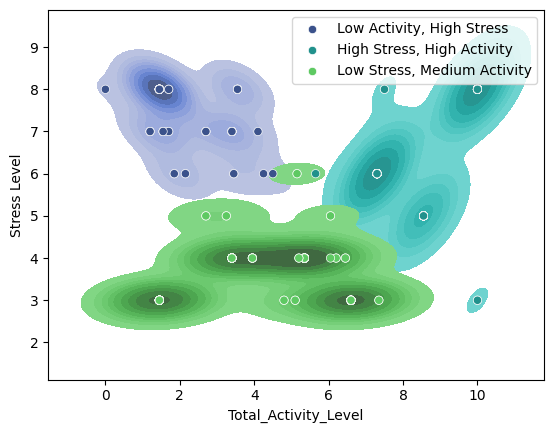

In [18]:
from sklearn.cluster import KMeans

physical_activity_cols = ['Physical Activity Level', 'Daily Steps', 'Stress Level']
# Note, I was able to get a cleaner division between clusters when I used the original data here compared to the normalized version.
df_clusters3= df_clean[physical_activity_cols]
kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(df_clusters3)
df_agg['Cluster3'] = kmeans.labels_
df_agg['Cluster3_Name'] = df_agg['Cluster3'].map(
    {0: 'Low Stress, Medium Activity', 1: 'High Stress, High Activity', 2: 'Low Activity, High Stress'})
sns.kdeplot(data=df_agg, x="Total_Activity_Level", y="Stress Level", hue="Cluster3_Name", fill=True, palette="viridis")
sns.scatterplot(data=df_agg, x="Total_Activity_Level", y="Stress Level", hue="Cluster3_Name", palette="viridis");
plt.legend();

*Figure shows a plot of total activity level vs stress with three distinct clusters.*
#### Observations
- Three clusters show up in the resulting data
  - Low Stress, Medium Activity
  - High Stress, Low Activity
  - High Stress, High Activity
- I suspect the distinct clusters may be determined by whether someone's activity levels are related to their job or not.

Note: since the K-Means algorithm is not deterministic, I locked down the seed for this section.

In [19]:
cluster0 = df_agg[df_agg["Cluster3_Name"] == "Low Stress, Medium Activity"]
cluster1 = df_agg[df_agg["Cluster3_Name"] == "High Stress, High Activity"]
cluster2 = df_agg[df_agg["Cluster3_Name"] == "Low Activity, High Stress"]
cluster_list = [cluster0, cluster1, cluster2]
df_cluster_agg = pd.DataFrame(columns=["Mean Steps", "Mean Activity Level", "Stress Level"])
for(cluster, cluster_name) in zip(cluster_list, ["Cluster 0", "Cluster 1", "Cluster 2"]):
    df_cluster_agg.loc[cluster_name] = [cluster['Daily Steps'].mean(), cluster['Physical Activity Level'].mean(), cluster['Stress Level'].mean()]
df_cluster_agg.round(2)



,Mean Steps,Mean Activity Level,Stress Level
Cluster 0,6216.33,54.76,3.60
Cluster 1,8825.88,83.41,6.54
Cluster 2,5365.00,35.42,7.43


*Figure chart of mean steps, mean activity, and mean stress level by cluster.*
### Observations
- More analysis could be done on this data by looking at other columns in the dataframe, along with what types of physical activities individuals in this group engage in.


### Ideal Daily Step Count

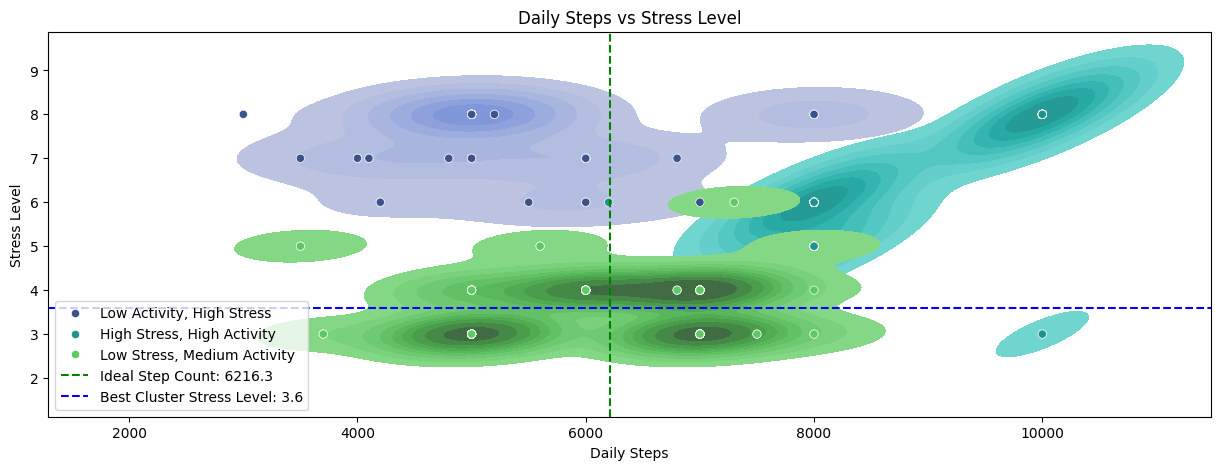

In [20]:
import matplotlib.pyplot as plt

plt, (ax1) = plt.subplots(1, 1, figsize=(15, 5))

# Calculate medians
mean_steps_total = df_agg["Daily Steps"].mean()
mean_activity_total = df_agg["Physical Activity Level"].mean()
mean_low_stress_step_count = df_agg[df_agg["Cluster3_Name"] == "Low Stress, Medium Activity"]["Daily Steps"].mean()
mean_low_stress_activity = df_agg[df_agg["Cluster3_Name"] == "Low Stress, Medium Activity"]["Physical Activity Level"].mean()
mean_stress_level = df_agg[df_agg["Cluster3_Name"] == "Low Stress, Medium Activity"]["Stress Level"].mean()

# Create subplots with median lines
ax1.set_title("Daily Steps vs Stress Level")
sns.kdeplot(data=df_agg, x="Daily Steps", y="Stress Level", hue="Cluster3_Name", fill=True, palette="viridis", ax=ax1)
sns.scatterplot(data=df_agg, x="Daily Steps", y="Stress Level", hue="Cluster3_Name", palette="viridis", ax=ax1)
ax1.axvline(x=mean_low_stress_step_count, color='green', linestyle='--',
            label=f'Ideal Step Count: {mean_low_stress_step_count:.1f}')

ax1.axhline(y=mean_stress_level, color='blue', linestyle='--', label=f'Best Cluster Stress Level: {mean_stress_level:.1f}')
ax1.legend(loc='lower left')

plt.savefig(THREE_CLUSTER_IMAGE_EXTENDED)


*Figure shows three cluster images with an ideal daily step count marked*
### Clusters Generated
- Blue (Low activity, high stress): concentrated at lower step counts (~2,500–6,000) with stress mostly 6–8.
- Teal/green (High stress, high activity): concentrated at higher steps (~7,500–11,000) with stress ~5–8.
- Light green (Low stress, medium activity): concentrated around ~4,000–8,000 steps with stress ~2–5.
### Observations
- The vertical green dashed line marks the “ideal” mean step count ≈ 6,216 steps; many low-stress, medium-activity points lie near this value.
- The horizontal blue dashed line marks the best cluster mean stress ≈ 3.6, highlighting the low-stress cluster’s central stress level.
- Overlap region around ~6,000 – 8,000 steps contains mixed stress outcomes, indicating step count alone does not determine stress.
- Directional pattern: higher activity subgroups (both medium and high activity) include both low- and high-stress individuals, while the lowest-activity group tends toward higher stress.
### Implication
Targeting ~6,200 daily steps aligns with the low-stress, medium-activity cluster, but activity level is not the sole driver of stress—other factors likely moderate stress within each activity group.


### Stability of Three Cluster Model
Kernel density plots were used to visualize the distribution of activity and stress within each cluster. The results show that while the clusters occupy distinct regions at the aggregate level, there is a noticeable overlap between groups and differences in spread, particularly for the smallest cluster. This suggests that the segmentation reflects general population structure but that cluster boundaries are not sharply defined.

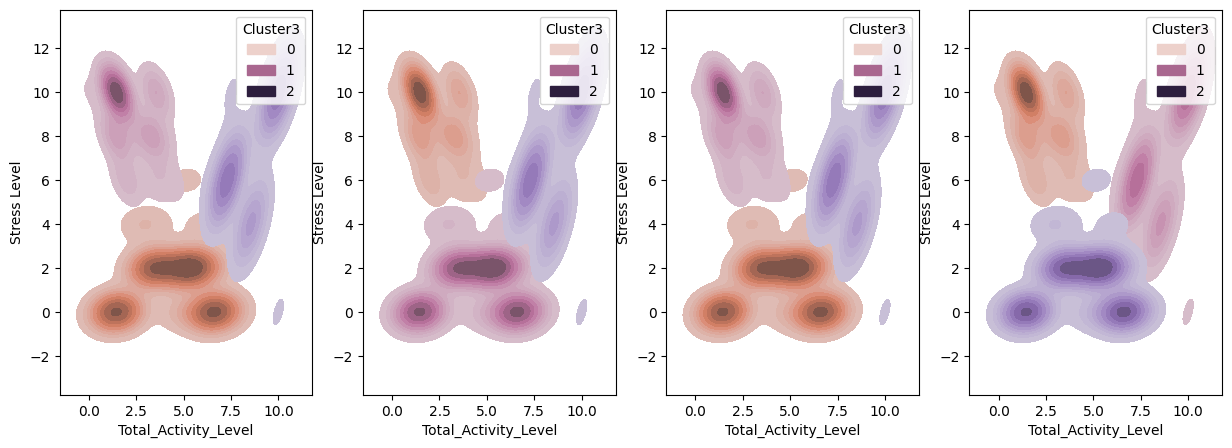

In [21]:
import matplotlib.pyplot as plt
def graph_cluster_stability(df, num_clusters):
    fig, (ax1, ax2, ax3, ax4)= plt.subplots(1, 4, figsize=(15, 5))
    for(ax, cluster) in zip([ax1, ax2, ax3, ax4], [0, 1, 2, 3]):
        physical_activity_cols = ['Physical Activity Level', 'Daily Steps', 'Stress Level']
        df_cl = df[physical_activity_cols]
        kmeans = KMeans(n_clusters=num_clusters)
        kmeans.fit(df_cl)
        df_cl['Cluster3'] = kmeans.labels_
        df_cl['Total_Activity_Level'] = (df_cl['Physical Activity Level'] + df_cl['Daily Steps']) / 2
        # Create subplots
        sns.kdeplot(data=df_cl, x="Total_Activity_Level", y="Stress Level", hue="Cluster3", fill=True, ax=ax, warn_singular=False)
graph_cluster_stability(df_normalized, 3)

*Figure k-Means algorithm was run multiple times with k=3 to determine cluster stability*
### Observation
- The stability of the 3-cluster model varies from run to run, but it feels stable enough that it's likely the clusters found in this section reflect correlations in the real world population.
- I ran the 3-cluster model with both the original and the normalized data and found the original data behaved slightly more predictable.

## Two Cluster Analyses
The two-cluster analysis represents the primary segmentation of the population based on activity–stress gradients. This model was selected for the main analysis due to its stability and interpretability, clearly separating individuals with generally positive versus negative patterns. In this section, we examine cluster assignments, visualize their distribution across features, and discuss the implications for understanding overall activity–stress structure.

### Plotting Total Physical Activity with Two Clusters

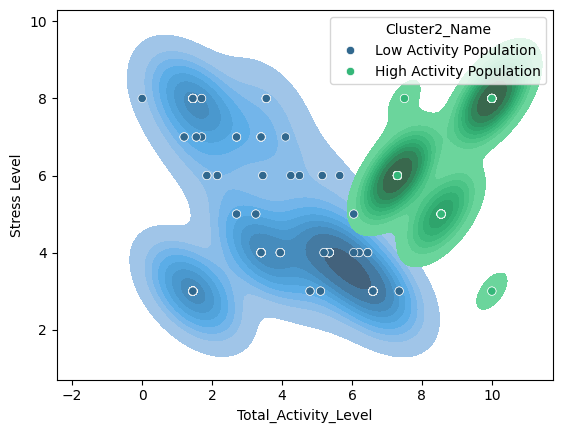

In [22]:
physical_activity_cols = ['Physical Activity Level', 'Daily Steps', 'Stress Level']
df_clusters = df_normalized[physical_activity_cols]
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(df_clusters)
df_agg['Cluster2'] = kmeans.labels_
df_agg['Cluster2_Name'] = df_agg['Cluster2'].map(
    {0: 'Low Activity Population', 1: 'High Activity Population'})


# Create subplots
sns.kdeplot(data=df_agg, x="Total_Activity_Level", y="Stress Level", hue="Cluster2_Name", fill=True, palette="viridis")
sns.scatterplot(data=df_agg, x="Total_Activity_Level", y="Stress Level", hue="Cluster2_Name", palette="viridis");


*Figure shows two clusters of individuals on the Stress vs. Activity Level Chart*
#### Observations
- In the low-activity population it looks like additional physical activity reduces stress, where as in the high-activity population additional physical activity increases stress. 
- Based on this data, the people with the least total stress have an average total activity level.

Note: since the K-Means algorithm is not deterministic, I locked down the seed for this section.




### Showing Clusters with Original Features

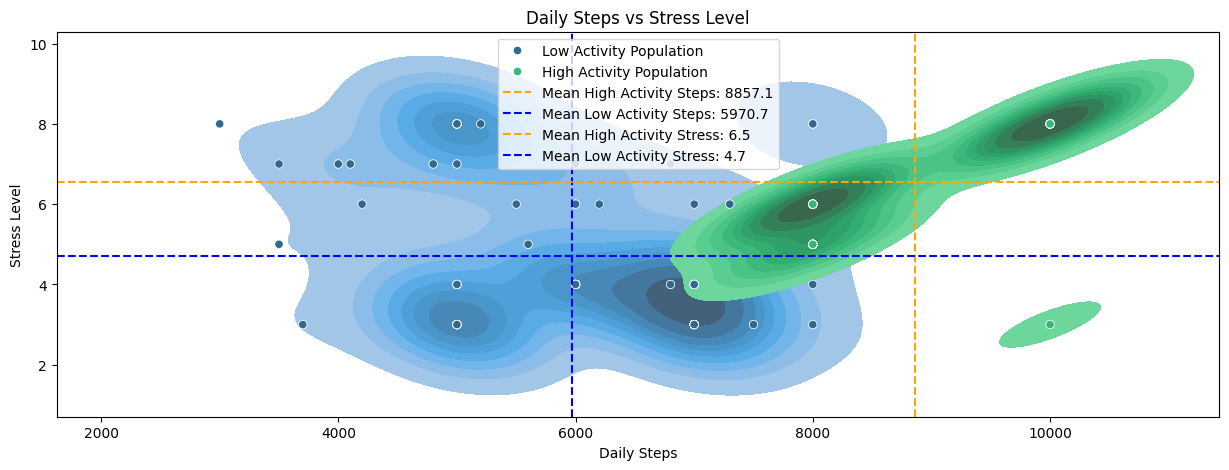

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

# Calculate medians
cluster1of2 = df_agg[df_agg["Cluster2"] == 0]
cluster2of2 = df_agg[df_agg["Cluster2"] == 1]

# Use the ideal step count and activity level calculated earlier.
low_activity_step_count = cluster1of2["Daily Steps"].mean()
high_activity_step_count = cluster2of2["Daily Steps"].mean()
low_activity_stress_level = cluster1of2["Stress Level"].mean()
high_activity_stress_level = cluster2of2["Stress Level"].mean()

# Create subplots with median lines
plt.title("Daily Steps vs Stress Level")
sns.kdeplot(data=df_agg, x="Daily Steps", y="Stress Level", hue="Cluster2_Name", fill=True, palette="viridis")
sns.scatterplot(data=df_agg, x="Daily Steps", y="Stress Level", hue="Cluster2_Name", palette="viridis")
plt.axvline(x=high_activity_step_count, color='orange', linestyle='--',
            label=f'Mean High Activity Steps: {high_activity_step_count:.1f}')
plt.axvline(x=low_activity_step_count, color='blue', linestyle='--',
            label=f'Mean Low Activity Steps: {low_activity_step_count:.1f}')

plt.axhline(y=high_activity_stress_level, color='orange', linestyle='--',
            label=f'Mean High Activity Stress: {high_activity_stress_level:.1f}')
plt.axhline(y=low_activity_stress_level, color='blue', linestyle='--',
            label=f'Mean Low Activity Stress: {low_activity_stress_level:.1f}')

plt.legend(loc='upper center');
plt.savefig(TWO_CLUSTER_IMAGE_EXTENDED)

*Figure shows two cluster models with population level mean for Daily steps and physical activity levels.*
#### Observations
- Two distinct activity populations are visible: a low-activity group (blue) concentrated between ~2,500–7,000 steps and a high-activity group (green) concentrated from ~7,500–11,000 steps.
- Mean step counts are marked: low activity ≈ 5,971 steps (blue dashed line) and high-activity ≈ 8,857 steps (orange dashed line).
- Mean stress levels differ by group: low-activity mean stress ≈ 4.7 (blue horizontal) versus high-activity mean stress ≈ 6.5 (orange horizontal).
- The high-activity population clusters at both higher step counts and generally higher stress scores (mostly 5–9), suggesting a positive association between step count and stress within that subgroup.
- The low-activity population shows broader stress variability (roughly 2–8) with many individuals at lower stress levels, indicating weaker or no clear positive relationship between steps and stress for this group.
Overlap region (around 6,000–8,000 steps) contains mixed stress values, implying individual differences rather than a strict step→stress effect across the whole sample.
- A few outliers exist at very high step counts (>10,000) with moderate-to-high stress and at low steps with both low and high stress, highlighting heterogeneity in the dataset.
##### Implication
Activity level alone does not uniformly predict stress—while the higher-activity subgroup tends toward higher stress, the low-activity group exhibits wide stress outcomes, so additional factors likely influence stress.

### Verifying clusters are stable
Kernel density plots were used to visualize the distribution of activity and stress within each cluster. The results show that while the clusters occupy distinct regions at the aggregate level, there is noticeable overlap between groups and differences in spread, particularly for the smallest cluster. This suggests that the segmentation reflects general population structure but that cluster boundaries are not sharply defined.

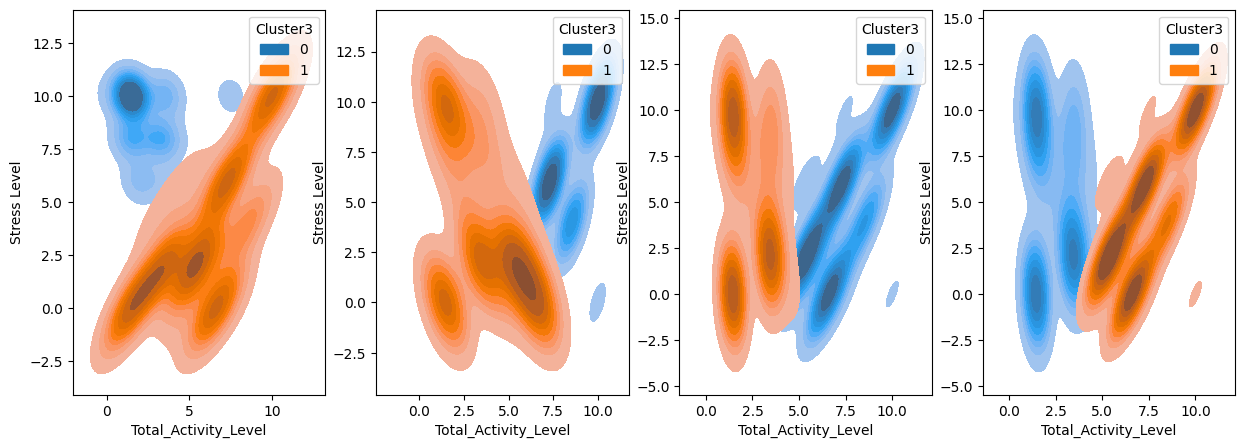

In [24]:
import matplotlib.pyplot as plt
graph_cluster_stability(df_normalized, 2)

*Figure shows multiple runs of k-means with k=2 to test cluster stability*
##### Observation
- The 2-cluster and model and the 3-cluster model are both a bit unstable, but I think they are both stable enough that they are likely to identify real world correlations in the underling data.
- In this data set I used the 3-cluster dataset to split the population into low and high-stressed individuals while the two cluster datasets were used to split the population into low and high-activity individuals.


### Cluster Regression Lines

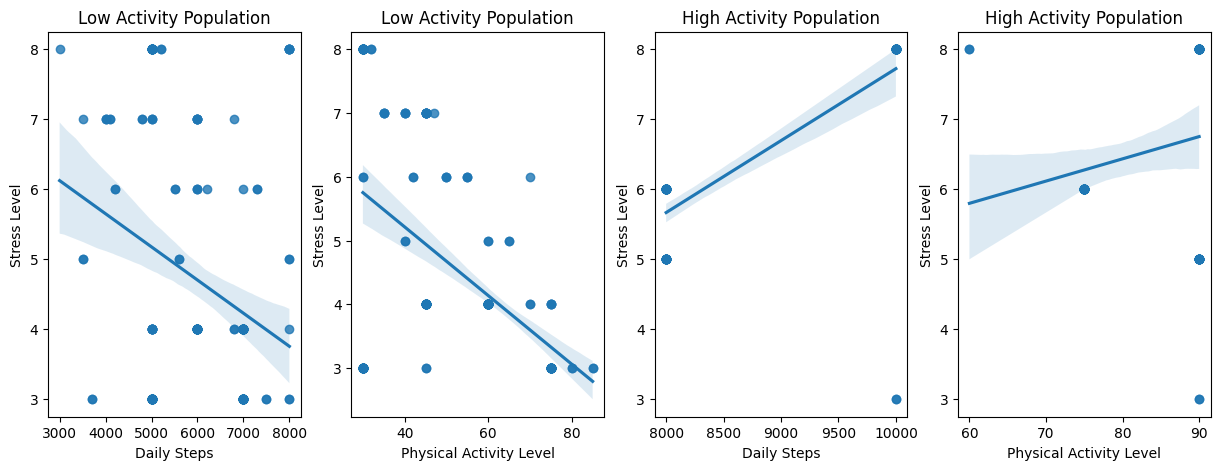

In [25]:
# Plotting regression line by cluster
df_agg['Occupation'] = df_clean['Occupation']
cluster0 = df_agg[df_agg["Cluster2"] == 0]
cluster1 = df_agg[df_agg["Cluster2"] == 1]
fix, axs = plt.subplots(1, 4, figsize=(15, 5))
ax1, ax2, ax3, ax4 = axs.ravel()

ax1.set_title("Low Activity Population")
sns.regplot(cluster0, x="Daily Steps", y="Stress Level", ax=ax1)

ax2.set_title("Low Activity Population")
sns.regplot(cluster0, x="Physical Activity Level", y="Stress Level", ax=ax2)

ax3.set_title("High Activity Population")
sns.regplot(cluster1, x="Daily Steps", y="Stress Level", ax=ax3)

ax4.set_title("High Activity Population")
sns.regplot(cluster1, x="Physical Activity Level", y="Stress Level", ax=ax4)
plt.tight_layout;

*Figure shows the correlation line for "Stress Level vs. Physical Activity" and "Stress Level vs. Daily Steps" in both the low-activity population and the high-activity population.*
#### Observation
- For the Low Activity population there is a clear negative trend line as physical activity and daily steps increase. This means that people who have a lower than average activity can reduce their daily stress significantly by increasing their base level of physical activity.
- On the other hand, the high-activity population has a positive trend line for the graph, meaning as they increase their physical activity levels, their stress levels go up rather than down.
- The High Activity Population also appears to be smaller than the Low Activity Population, which might affect the stability of our model.

### Two Cluster Summaries
K-means clustering was run multiple times to assess the stability of the segmentation. The two-cluster structure appeared consistent across most runs, although variation occurred when one cluster contained relatively few observations. This indicates that the overall grouping is present but that one subgroup is less well-separated and more sensitive to initialization.

## Activity Levels by Occupation
The relationship between activity and stress was also examined within individual occupations. In most cases, the aggregate pattern did not persist, and clear correlations were often driven by a small number of extreme observations. This suggests that the population-level structure is influenced more by differences between occupations than by consistent within-occupation relationships.

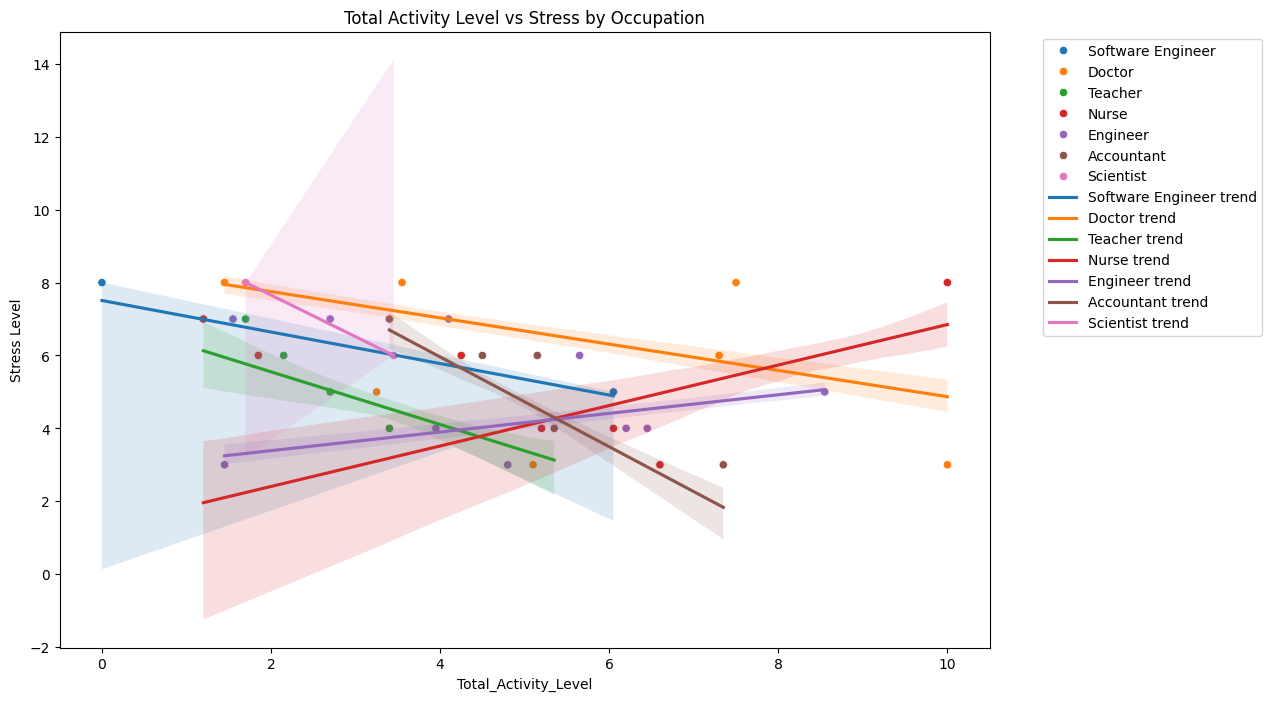

In [26]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_agg, x='Total_Activity_Level', y='Stress Level', hue='Occupation')
for occupation in df_agg['Occupation'].unique():
    occupation_data = df_agg[df_agg['Occupation'] == occupation]
    sns.regplot(data=occupation_data, x='Total_Activity_Level', y='Stress Level', 
                scatter=False, label=f'{occupation} trend')
plt.title('Total Activity Level vs Stress by Occupation')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left');



*Figure plots Stress vs. Activity Level for each occupation*

### Observation
- Of the occupations listed, two show a positive trend line. ["Nurse", and "Engineer"] All other occupations show a negative trend line.

### Low vs. High Stress Occupations

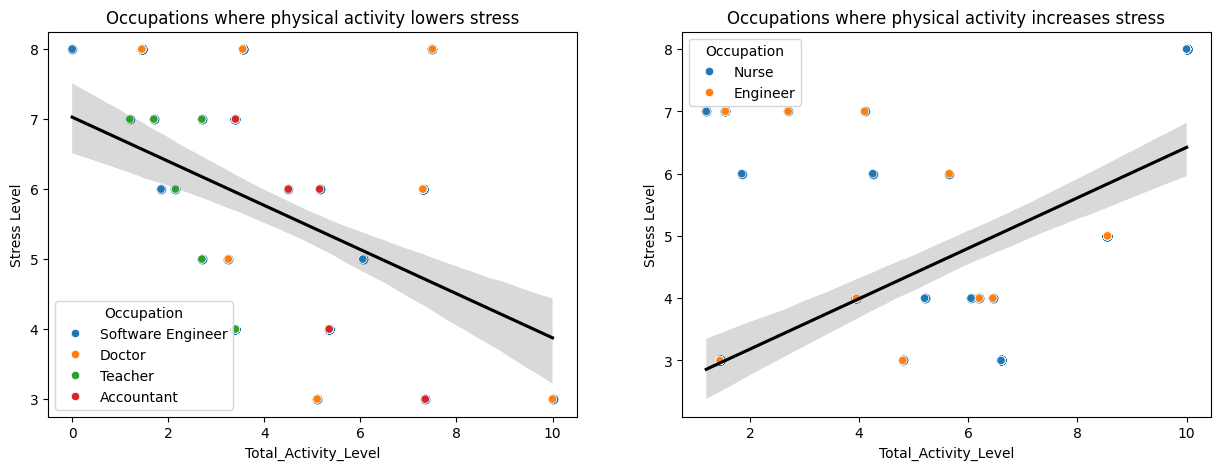

In [27]:
negative_correlation = ["Software Engineer", "Doctor", "Teacher", "Accountant"]
positive_correlation = ["Nurse", "Engineer"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
sns.regplot(df_agg[df_agg['Occupation'].isin(negative_correlation)], x="Total_Activity_Level", y="Stress Level", ax=ax1, line_kws={"color": "black"})
sns.scatterplot(df_agg[df_agg['Occupation'].isin(negative_correlation)], x="Total_Activity_Level", y="Stress Level", ax=ax1, hue="Occupation")
ax1.set_title("Occupations where physical activity lowers stress")

sns.regplot(df_agg[df_agg['Occupation'].isin(positive_correlation)], x="Total_Activity_Level", y="Stress Level", ax=ax2, line_kws={"color": "black"})
sns.scatterplot(df_agg[df_agg['Occupation'].isin(positive_correlation)], x="Total_Activity_Level", y="Stress Level", ax=ax2, hue="Occupation")
ax2.set_title("Occupations where physical activity increases stress");


*Figure plots regression lines for stress vs. activity. Separating data into occupations with a negative stress vs. activity correlation (left) and occupations with a positive stress vs. activity correlation (right)*
### Final Observations
- Looking at the scatter plots of the two sets of occupations, it looks like the two occupations with a positive correlation between stress and total activity levels are likely caused by outliers.
- This indicates that although the 3 clusters I described early appear in aggregate, the hypothesis that they may be linked to occupation is not shown in this data.

### Side by Side Clusters

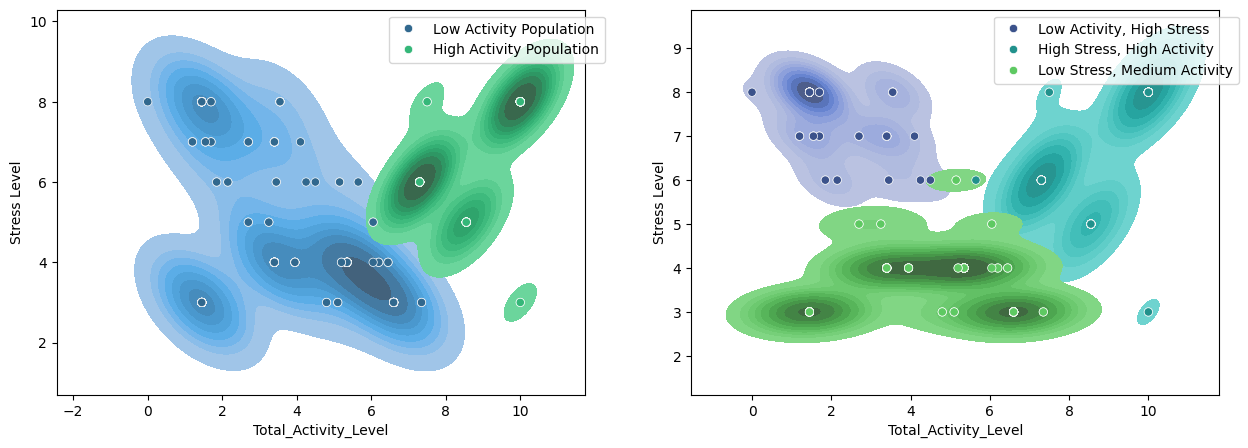

In [28]:
# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

sns.kdeplot(data=df_agg, x="Total_Activity_Level", y="Stress Level", hue="Cluster2_Name", fill=True, palette="viridis", ax=ax1)
sns.scatterplot(data=df_agg, x="Total_Activity_Level", y="Stress Level", hue="Cluster2_Name", palette="viridis", ax=ax1)

sns.kdeplot(data=df_agg, x="Total_Activity_Level", y="Stress Level", hue="Cluster3_Name", fill=True, palette="viridis", ax=ax2)
sns.scatterplot(data=df_agg, x="Total_Activity_Level", y="Stress Level", hue="Cluster3_Name", palette="viridis", ax=ax2)
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper right')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper right')
img = fig.savefig(SIDE_BY_SIDE_CLUSTERS)

*Figure shows two cluster model and three cluster models for Total_Activity_Level displayed next to each other.*
# Notebook Summary

This project explores the relationship between total activity levels and self-reported stress across different occupations. The goal was to identify whether higher activity is associated with increased stress and whether occupation plays a meaningful role in that relationship.

The analysis includes:
- Data cleaning and occupation-level filtering
- Exploratory data analysis (EDA)
- Correlation analysis
- K-means clustering to identify patterns in activity and stress


Several distinct clusters were identified when analyzing the full dataset, suggesting meaningful population-level groupings. However, when the data were examined within individual occupations, these cluster patterns were not consistently reproduced. In several cases, clear correlations appeared to be influenced by outliers rather than stable occupation-level trends.

These results suggest that the relationship between activity and stress is more visible at the aggregate level than within specific occupations. Several occupations were also excluded due to insufficient sample sizes, limiting subgroup analysis.

This project uses the Sleep Health and Lifestyle Dataset from Kaggle dataset.
https://www.kaggle.com/datasets/uom190346a/sleep-health-and-lifestyle-dataset

## Methodology
In this project I created a combined metric called Total_Physical_Activity which combined the data from the Daily Steps a Physical Activity Column. This allowed me to create more readable charts and allowed be to quickly determine the correlation between different samples within clusters.
## Experiments
On looking at the initial Stress vs. Physical Activity data, I saw what looked like 2–3 distinct clusters in the raw data, so I ran the kmeans algorithm on the data twice, once for two clusters and once for three. I found that both cluster groups were potentially useful. The two cluster data were more stable over time; therefore, I think it's a more accurate description of the underling patterns.

## Findings
When looking closely at the two cluster data, I found that the low-activity population had a negative correlation between stress and activity levels while the high-activity population had a positive correlation. I hypothesized that this correlation could have been linked to occupation, but when I looked closer at the occupation data, I found that there wasn't enough data in my dataset to get concrete conclusions from it. Even the individual occupations which showed a positive stress vs. activity correlation didn't show as strong a correlation once I looked at the raw data. This was likely due to several occupations having insufficient sample sizes for detailed analysis.

These results suggest that the relationship between activity and stress is more visible at the aggregate level than within specific occupations.

## Final Observations
- Individuals with a below-average physical activity level could reduce stress by increasing their total activity levels.
- Individuals with above-average activity can reduce stress by lowering their activity levels.
- Based on this dataset, the ideal daily step count came out to be 6200.

We analyzed if the different correlations could be caused by a person's occupation but found there was not enough data in the dataset to get any conclusive information about that.

## Conclusion
Distinct clusters were observed at the aggregate level, demonstrating that population structure exists in activity–stress behavior.
The two-cluster solution was selected for the main analysis because it provides a clear and interpretable separation.
However, the three-cluster solution can be useful for identifying subgroups, such as low-stress individuals.

Occupation-level analyses revealed that within-group correlations were weak and often influenced by extreme observations,
highlighting that the aggregate patterns are driven primarily by differences between groups rather than consistent
relationships within occupations.

Finally, the dataset appears to be synthetic, with unusually uniform distributions for some features,
which underscores the importance of testing assumptions and documenting limitations.

These insights provide a robust and reproducible foundation for exploring population structure in activity–stress data
and for guiding future work with additional or real-world datasets.

## Additional Observations
- Efforts to improve sleep duration and sleep quality have a huge effect on overall health.
- There was a strong correlation between heart rate and stress levels.